# Amino Acid 2D Structures
Generate clean 2D chemical structure images for all 20 standard amino acids using RDKit.

In [13]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from IPython.display import display, SVG
from pathlib import Path

# All 20 standard amino acids: (3-letter, 1-letter, name, SMILES)
# SMILES use zwitterionic form at physiological pH (NH3+, COO-)
# Side chains with pKa < 7.4 are shown charged (Asp, Glu deprotonated; Lys, Arg protonated; His neutral)
AMINO_ACIDS = [
    ("Ala", "A", "Alanine",       "C[C@@H]([NH3+])C(=O)[O-]"),
    ("Arg", "R", "Arginine",      "[NH2+]=C(N)NCCC[C@@H]([NH3+])C(=O)[O-]"),
    ("Asn", "N", "Asparagine",    "NC(=O)C[C@@H]([NH3+])C(=O)[O-]"),
    ("Asp", "D", "Aspartic acid", "[O-]C(=O)C[C@@H]([NH3+])C(=O)[O-]"),
    ("Cys", "C", "Cysteine",      "SC[C@@H]([NH3+])C(=O)[O-]"),
    ("Gln", "Q", "Glutamine",     "NC(=O)CC[C@@H]([NH3+])C(=O)[O-]"),
    ("Glu", "E", "Glutamic acid", "[O-]C(=O)CC[C@@H]([NH3+])C(=O)[O-]"),
    ("Gly", "G", "Glycine",       "[NH3+]CC(=O)[O-]"),
    ("His", "H", "Histidine",     "c1c[nH]c(C[C@@H]([NH3+])C(=O)[O-])n1"),
    ("Ile", "I", "Isoleucine",    "CC[C@H](C)[C@@H]([NH3+])C(=O)[O-]"),
    ("Leu", "L", "Leucine",       "CC(C)C[C@@H]([NH3+])C(=O)[O-]"),
    ("Lys", "K", "Lysine",        "[NH3+]CCCC[C@@H]([NH3+])C(=O)[O-]"),
    ("Met", "M", "Methionine",    "CSCC[C@@H]([NH3+])C(=O)[O-]"),
    ("Phe", "F", "Phenylalanine", "c1ccc(C[C@@H]([NH3+])C(=O)[O-])cc1"),
    ("Pro", "P", "Proline",       "[O-]C(=O)[C@@H]1CCC[NH2+]1"),
    ("Ser", "S", "Serine",        "OC[C@@H]([NH3+])C(=O)[O-]"),
    ("Thr", "T", "Threonine",     "C[C@H](O)[C@@H]([NH3+])C(=O)[O-]"),
    ("Trp", "W", "Tryptophan",    "c1ccc2c(C[C@@H]([NH3+])C(=O)[O-])c[nH]c2c1"),
    ("Tyr", "Y", "Tyrosine",      "Oc1ccc(C[C@@H]([NH3+])C(=O)[O-])cc1"),
    ("Val", "V", "Valine",        "CC(C)[C@@H]([NH3+])C(=O)[O-]"),
]

# Parse and generate 2D coords
mols = []
labels = []
for three, one, name, smiles in AMINO_ACIDS:
    mol = Chem.MolFromSmiles(smiles)
    AllChem.Compute2DCoords(mol)
    mols.append(mol)
    labels.append(f"{name} ({three}, {one})")

print(f"Loaded {len(mols)} amino acids")

Loaded 20 amino acids


In [14]:
import re
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, HTML
import numpy as np

# SMARTS for the amino acid backbone: N-Calpha-C(=O)-O
BACKBONE_SMARTS = Chem.MolFromSmarts("[NX4,NX3:1][CX4:2][CX3:3](=[OX1:4])[OX1,OX2:5]")

# Style config
BACKBONE_OPACITY = 0.3
IMG_W, IMG_H = 350, 300

# Group definitions in blog post order: (group name, 1-letter codes, RGBA background color)
GROUPS = [
    ("Nonpolar / Aromatic",   "AVILMFYW", (1.0, 0.85, 0.85, 1.0)),   # pinkish red
    ("Positively Charged",    "RHK",      (0.85, 1.0, 0.85, 1.0)),   # light green
    ("Negatively Charged",    "DE",       (0.75, 0.93, 0.75, 1.0)),   # dark green
    ("Polar Uncharged",       "STNQ",     (1.0, 0.92, 0.80, 1.0)),   # orangish
    ("Special",               "CGP",      (1.0, 1.0, 0.82, 1.0)),    # yellow
]

# Build lookup: 1-letter code -> background color
AA_BG = {}
for _, codes, color in GROUPS:
    for code in codes:
        AA_BG[code] = color

def get_backbone_match(mol):
    return mol.GetSubstructMatch(BACKBONE_SMARTS)

def get_backbone_atoms(mol):
    match = get_backbone_match(mol)
    if not match:
        return set()
    backbone = set(match)
    for idx in list(backbone):
        atom = mol.GetAtomWithIdx(idx)
        for neighbor in atom.GetNeighbors():
            if neighbor.GetAtomicNum() == 1:
                backbone.add(neighbor.GetIdx())
    return backbone

def get_backbone_bonds(mol, backbone_atoms):
    bonds = set()
    for bond in mol.GetBonds():
        if bond.GetBeginAtomIdx() in backbone_atoms and bond.GetEndAtomIdx() in backbone_atoms:
            bonds.add(bond.GetIdx())
    return bonds

def get_sidechain_atom(mol):
    match = get_backbone_match(mol)
    if not match:
        return None
    ca_idx, n_idx, c_idx = match[1], match[0], match[2]
    ca_atom = mol.GetAtomWithIdx(ca_idx)
    for neighbor in ca_atom.GetNeighbors():
        nidx = neighbor.GetIdx()
        if nidx != n_idx and nidx != c_idx and neighbor.GetAtomicNum() != 1:
            return nidx
    return None

def rotate_mol(mol, angle, center):
    conf = mol.GetConformer()
    cos_r, sin_r = np.cos(angle), np.sin(angle)
    for i in range(mol.GetNumAtoms()):
        pos = np.array(conf.GetAtomPosition(i))[:2]
        rel = pos - center
        new_rel = np.array([cos_r * rel[0] - sin_r * rel[1],
                            sin_r * rel[0] + cos_r * rel[1]])
        new_pos = center + new_rel
        conf.SetAtomPosition(i, (float(new_pos[0]), float(new_pos[1]), 0.0))

def mirror_horizontal(mol, x_axis):
    conf = mol.GetConformer()
    for i in range(mol.GetNumAtoms()):
        pos = np.array(conf.GetAtomPosition(i))[:2]
        conf.SetAtomPosition(i, (float(2 * x_axis - pos[0]), float(pos[1]), 0.0))

def orient_molecule(mol):
    match = get_backbone_match(mol)
    if not match:
        return
    conf = mol.GetConformer()
    ca_pos = np.array(conf.GetAtomPosition(match[1]))[:2]

    sc_idx = get_sidechain_atom(mol)
    if sc_idx is not None:
        target_pos = np.array(conf.GetAtomPosition(sc_idx))[:2]
        vec = target_pos - ca_pos
        current_angle = np.arctan2(vec[1], vec[0])
        rotation = np.pi / 2 - current_angle
    else:
        c_pos = np.array(conf.GetAtomPosition(match[2]))[:2]
        vec = c_pos - ca_pos
        current_angle = np.arctan2(vec[1], vec[0])
        rotation = -np.pi / 2 - current_angle

    rotate_mol(mol, rotation, ca_pos)

    new_ca_pos = np.array(conf.GetAtomPosition(match[1]))[:2]
    new_c_pos = np.array(conf.GetAtomPosition(match[2]))[:2]
    if new_c_pos[0] > new_ca_pos[0]:
        mirror_horizontal(mol, new_ca_pos[0])

    Chem.WedgeMolBonds(mol, conf)

def dim_backbone_svg(svg, backbone_atoms, backbone_bonds, backbone_coords):
    opacity = BACKBONE_OPACITY

    for idx in backbone_atoms:
        svg = re.sub(
            rf"(<path class='atom-{idx}')",
            rf"\1 opacity='{opacity}'",
            svg,
        )

    for idx in backbone_bonds:
        svg = re.sub(
            rf"(<path class='bond-{idx}\b[^']*')",
            rf"\1 opacity='{opacity}'",
            svg,
        )

    def dim_unclassed_path(m):
        path_str = m.group(0)
        if "class=" in path_str:
            return path_str
        nums = re.findall(r'[\d.]+', m.group(1))
        try:
            points = [(float(nums[i]), float(nums[i+1])) for i in range(0, len(nums), 2)]
        except (ValueError, IndexError):
            return path_str
        for px, py in points:
            for ax, ay in backbone_coords.values():
                if abs(px - ax) < 5 and abs(py - ay) < 5:
                    return path_str.replace("<path ", f"<path opacity='{opacity}' ", 1)
        return path_str

    svg = re.sub(r"<path d='([^']+)'[^>]*/?>", dim_unclassed_path, svg)
    return svg

def add_alpha_label(svg, ca_x, ca_y):
    label = (
        f"<text x='{ca_x + 8}' y='{ca_y + 18}' "
        f"style='font-size:14px; font-style:italic; fill:#666666; "
        f"font-family:sans-serif;'>\u03b1</text>"
    )
    svg = svg.replace("</svg>", f"{label}\n</svg>")
    return svg

def draw_aa_svg(mol, one_letter, w=IMG_W, h=IMG_H):
    backbone_atoms = get_backbone_atoms(mol)
    backbone_bonds = get_backbone_bonds(mol, backbone_atoms)
    match = get_backbone_match(mol)

    orient_molecule(mol)

    bg = AA_BG.get(one_letter, (1.0, 1.0, 1.0, 1.0))

    drawer = rdMolDraw2D.MolDraw2DSVG(w, h)
    opts = drawer.drawOptions()
    opts.setBackgroundColour(bg)
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()

    backbone_coords = {}
    for idx in backbone_atoms:
        pt = drawer.GetDrawCoords(idx)
        backbone_coords[idx] = (pt.x, pt.y)

    svg = drawer.GetDrawingText()
    svg = dim_backbone_svg(svg, backbone_atoms, backbone_bonds, backbone_coords)

    if match:
        ca_pt = drawer.GetDrawCoords(match[1])
        svg = add_alpha_label(svg, ca_pt.x, ca_pt.y)

    return svg

# Build ordered list by group
ordered = []
for group_name, codes, color in GROUPS:
    for three, one, name, smiles in AMINO_ACIDS:
        if one in codes:
            idx = next(i for i, (t, o, n, s) in enumerate(AMINO_ACIDS) if o == one)
            ordered.append((three, one, name, mols[idx], labels[idx]))

# Preview grid as HTML, grouped with headers
html = ""
for group_name, codes, color in GROUPS:
    r, g, b, _ = color
    hex_bg = f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}"
    html += f"<h3 style='margin:16px 0 4px;'>{group_name}</h3>"
    html += f"<div style='display:grid; grid-template-columns: repeat(4, {IMG_W}px); gap:4px;'>"
    for three, one, name, mol, label in ordered:
        if one in codes:
            svg = draw_aa_svg(mol, one)
            html += f"<div style='text-align:center; background:{hex_bg}; border-radius:8px; padding:4px;'>{svg}<br><small>{label}</small></div>"
    html += "</div>"

display(HTML(html))

In [15]:
# Save individual SVGs for use in the blog post
out_dir = Path("../assets/img/amino-acids")
out_dir.mkdir(parents=True, exist_ok=True)

for (three, one, name, _), mol in zip(AMINO_ACIDS, mols):
    svg = draw_aa_svg(mol, one)
    fname = out_dir / f"{three.lower()}.svg"
    fname.write_text(svg)

print(f"Saved {len(mols)} SVGs to {out_dir.resolve()}")

Saved 20 SVGs to /Users/bviggiano/Projects/bviggiano.github.io/assets/img/amino-acids


Saved to /Users/bviggiano/Projects/bviggiano.github.io/assets/img/amino-acid-frequency.png


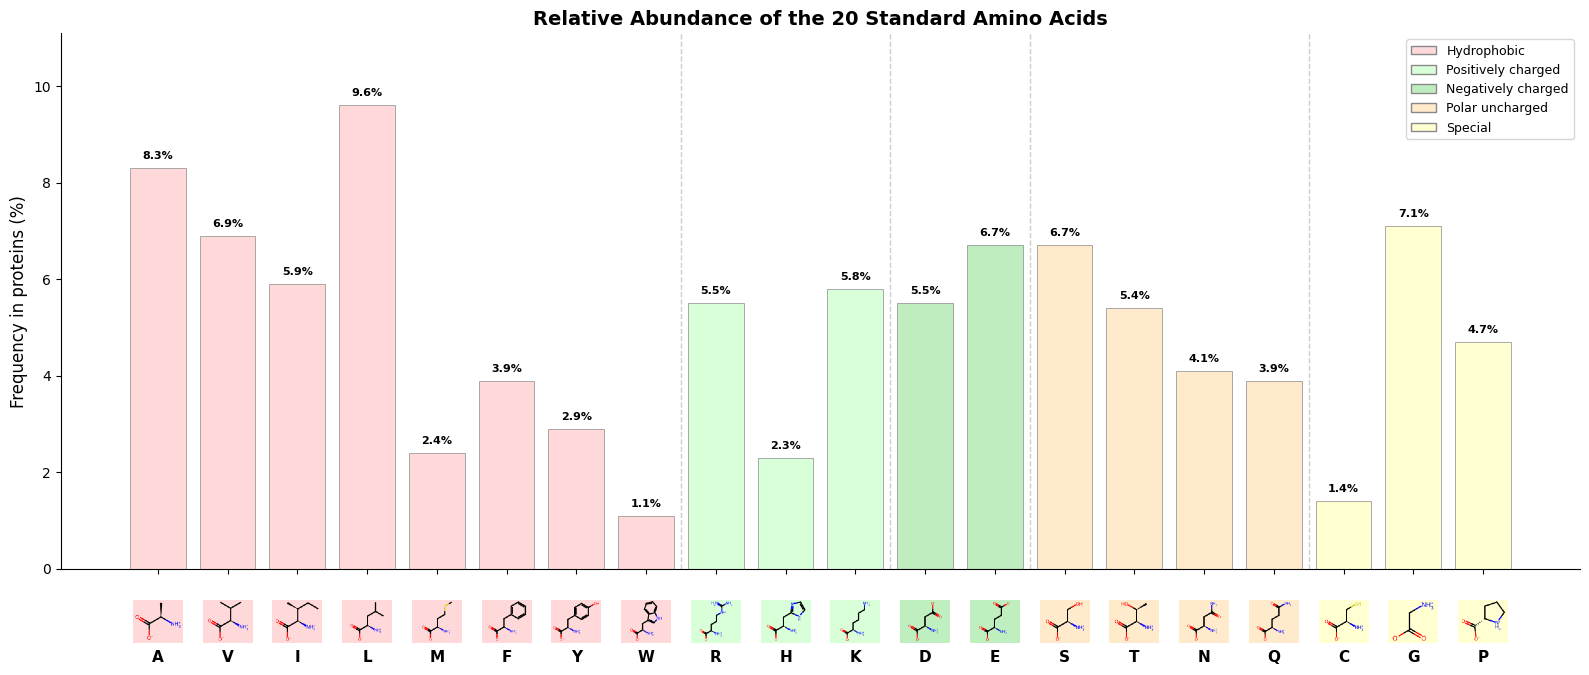

In [16]:
import matplotlib.pyplot as plt
from io import BytesIO
from pathlib import Path
from rdkit.Chem.Draw import rdMolDraw2D

# Amino acid frequencies from UniProtKB/Swiss-Prot release 2026_01
# Source: https://web.expasy.org/docs/relnotes/relstat.html
AA_FREQ = {
    "L": 9.6, "A": 8.3, "G": 7.1, "V": 6.9, "E": 6.7,
    "S": 6.7, "I": 5.9, "K": 5.8, "R": 5.5, "D": 5.5,
    "T": 5.4, "P": 4.7, "N": 4.1, "F": 3.9, "Q": 3.9,
    "Y": 2.9, "M": 2.4, "H": 2.3, "C": 1.4, "W": 1.1,
}

# Group colors matching the notebook groups
GROUP_COLORS = {
    "A": "#FFD9D9", "V": "#FFD9D9", "I": "#FFD9D9", "L": "#FFD9D9",
    "M": "#FFD9D9", "F": "#FFD9D9", "Y": "#FFD9D9", "W": "#FFD9D9",
    "S": "#FFEBCC", "T": "#FFEBCC", "N": "#FFEBCC", "Q": "#FFEBCC",
    "C": "#FFFFD1", "G": "#FFFFD1", "P": "#FFFFD1",
    "R": "#D9FFD9", "H": "#D9FFD9", "K": "#D9FFD9",
    "D": "#BFEDBF", "E": "#BFEDBF",
}

# Order matching the blog post: hydrophobic, positive, negative, polar, special
BLOG_ORDER = list("AVILMFYW") + list("RHK") + list("DE") + list("STNQ") + list("CGP")
codes = BLOG_ORDER
freqs = [AA_FREQ[aa] for aa in codes]
colors = [GROUP_COLORS[aa] for aa in codes]

# Map 1-letter to mol index for rendering
ONE_TO_IDX = {one: i for i, (_, one, _, _) in enumerate(AMINO_ACIDS)}

def render_aa_png(one_letter, w=80, h=68):
    """Render amino acid structure as PNG bytes using RDKit directly."""
    idx = ONE_TO_IDX[one_letter]
    mol = mols[idx]
    bg = AA_BG.get(one_letter, (1.0, 1.0, 1.0, 1.0))
    drawer = rdMolDraw2D.MolDraw2DCairo(w, h)
    opts = drawer.drawOptions()
    opts.setBackgroundColour(bg)
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    from PIL import Image
    return Image.open(BytesIO(drawer.GetDrawingText()))

# Create figure
fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.bar(range(len(codes)), freqs, color=colors, edgecolor="#888888", linewidth=0.5, width=0.8)

# Add percentage labels on bars
for i, (code, freq) in enumerate(zip(codes, freqs)):
    ax.text(i, freq + 0.15, f"{freq}%", ha="center", va="bottom", fontsize=8, fontweight="bold")

# Add structure images below x-axis
for i, code in enumerate(codes):
    try:
        img = render_aa_png(code)
        imagebox = plt.matplotlib.offsetbox.OffsetImage(img, zoom=0.45)
        ab = plt.matplotlib.offsetbox.AnnotationBbox(
            imagebox, (i, 0), xybox=(0, -38),
            xycoords=("data", "axes fraction"),
            boxcoords="offset points",
            frameon=False,
        )
        ax.add_artist(ab)
    except Exception as e:
        print(f"Could not load {code}: {e}")

# Add single-letter code below the image
ax.set_xticks(range(len(codes)))
ax.set_xticklabels(codes, fontsize=11, fontweight="bold")
ax.tick_params(axis="x", pad=55)

ax.set_ylabel("Frequency in proteins (%)", fontsize=12)
ax.set_title("Relative Abundance of the 20 Standard Amino Acids", fontsize=14, fontweight="bold")
ax.set_ylim(0, max(freqs) + 1.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Group divider lines
group_sizes = [8, 3, 2, 4, 3]  # hydrophobic, positive, negative, polar, special
pos = 0
for size in group_sizes[:-1]:
    pos += size
    ax.axvline(x=pos - 0.5, color="#cccccc", linewidth=1, linestyle="--")

# Legend for groups
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#FFD9D9", edgecolor="#888", label="Hydrophobic"),
    Patch(facecolor="#D9FFD9", edgecolor="#888", label="Positively charged"),
    Patch(facecolor="#BFEDBF", edgecolor="#888", label="Negatively charged"),
    Patch(facecolor="#FFEBCC", edgecolor="#888", label="Polar uncharged"),
    Patch(facecolor="#FFFFD1", edgecolor="#888", label="Special"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

# Save
out_path = Path("../assets/img/amino-acid-frequency.png")
fig.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="white")
print(f"Saved to {out_path.resolve()}")
plt.show()